# 02. Limpeza de Dados e Análise Exploratória (EDA)

Este notebook parte do dataset consolidado (`dataset_final.csv`, gerado no notebook 01) e percorre as seguintes etapas até produzir os conjuntos de treino e teste prontos para modelagem:

1. Carregamento e visão geral do dataset.
2. Filtragem das linhas com a variável alvo (`ATINGIU_META`) preenchida.
3. Análise Exploratória de Dados (EDA) com visualizações.
4. Engenharia de features e tratamento de valores faltantes.
5. Seleção de features por correlação com o alvo (metodologia da disciplina).
6. Divisão treino/teste estratificada e normalização com StandardScaler.
7. Exportação dos conjuntos finais para uso nos notebooks de modelagem.

In [1]:
%matplotlib inline
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importar funções do pacote src
sys.path.insert(0, os.path.abspath('..'))
from src.preprocessamento import criar_alunos_por_turma, tratar_faltantes_features, selecionar_features_por_correlacao

# Configurações de visualização
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Caminhos
DADOS_TRATADOS = os.path.abspath('../dados_tratados')

print('Imports e configurações carregados com sucesso.')

Imports e configurações carregados com sucesso.


---
## 1. Carregamento do Dataset

O arquivo `dataset_final.csv` contém dados de escolas da Paraíba com informações do Censo Escolar (infraestrutura, docentes, matrículas) cruzadas com as notas e metas do IDEB, organizados em formato de painel longitudinal (uma linha por escola por ano).

In [2]:
df = pd.read_csv(os.path.join(DADOS_TRATADOS, 'dataset_final.csv'), low_memory=False)
print(f'Shape do dataset: {df.shape}')
print(f'\nTipos de colunas:')
print(df.dtypes.value_counts())

Shape do dataset: (4767, 457)

Tipos de colunas:
float64    428
object      17
int64       12
Name: count, dtype: int64


---
## 2. Filtragem: Apenas Linhas com Alvo Preenchido

A coluna `ATINGIU_META` é a variável alvo do nosso problema de classificação binária. Ela é `NaN` para o ano de 2023 (e para escolas sem meta projetada em outros anos), pois o INEP não publicou metas a partir de 2021. As linhas sem alvo preenchido não podem ser usadas no treinamento supervisionado, portanto são removidas nesta etapa.

In [3]:
print(f'Shape ANTES do filtro: {df.shape}')
print(f'ATINGIU_META NaN: {df["ATINGIU_META"].isna().sum()}')

df_model = df.dropna(subset=['ATINGIU_META']).copy()

print(f'Shape DEPOIS do filtro: {df_model.shape}')
print(f'\nDistribuição do alvo:')
print(df_model['ATINGIU_META'].value_counts())

Shape ANTES do filtro: (4767, 457)
ATINGIU_META NaN: 1424
Shape DEPOIS do filtro: (3343, 457)

Distribuição do alvo:
ATINGIU_META
1.0    1861
0.0    1482
Name: count, dtype: int64


---
## 3. Análise Exploratória de Dados (EDA)

A análise exploratória tem como objetivo entender a distribuição das variáveis, identificar possíveis desbalanceamentos na variável alvo e verificar a relação inicial entre as características das escolas e o cumprimento da meta do IDEB.

### 3a. Distribuição da Variável Alvo (ATINGIU_META)

Verificamos se as classes estão balanceadas. Um desbalanceamento significativo pode exigir técnicas como amostragem estratificada na divisão treino/teste ou ajuste de pesos nos modelos.

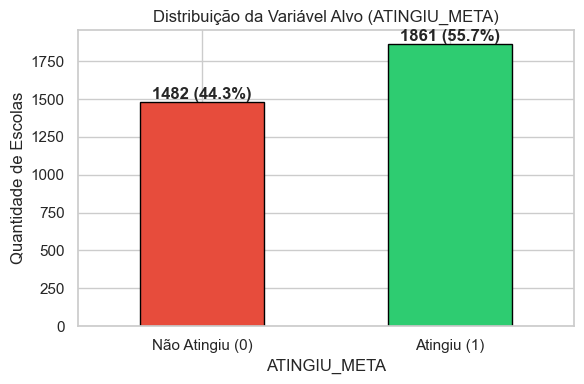

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
contagem = df_model['ATINGIU_META'].value_counts().sort_index()
cores = ['#e74c3c', '#2ecc71']
contagem.plot(kind='bar', color=cores, edgecolor='black', ax=ax)
ax.set_xticklabels(['Não Atingiu (0)', 'Atingiu (1)'], rotation=0)
ax.set_ylabel('Quantidade de Escolas')
ax.set_title('Distribuição da Variável Alvo (ATINGIU_META)')
for i, v in enumerate(contagem):
    ax.text(i, v + 20, f'{v} ({v/len(df_model)*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DADOS_TRATADOS, 'eda_atingiu_meta.png'), bbox_inches='tight')
plt.show()

### 3b. Distribuição da Nota IDEB

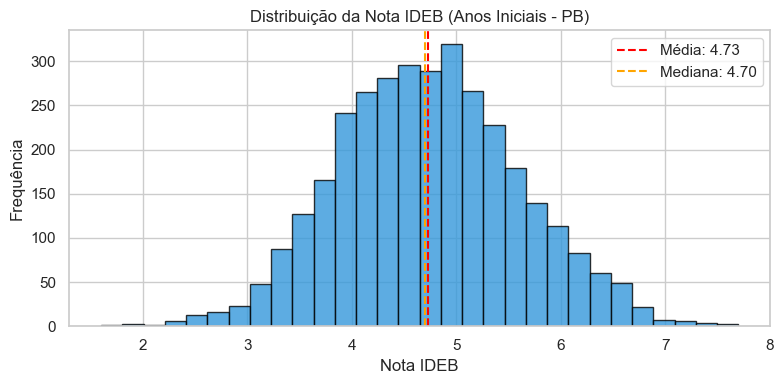

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df_model['IDEB'].hist(bins=30, edgecolor='black', color='#3498db', alpha=0.8, ax=ax)
ax.axvline(df_model['IDEB'].mean(), color='red', linestyle='--', label=f'Média: {df_model["IDEB"].mean():.2f}')
ax.axvline(df_model['IDEB'].median(), color='orange', linestyle='--', label=f'Mediana: {df_model["IDEB"].median():.2f}')
ax.set_xlabel('Nota IDEB')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição da Nota IDEB (Anos Iniciais - PB)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DADOS_TRATADOS, 'eda_distribuicao_ideb.png'), bbox_inches='tight')
plt.show()

### 3c. Relação entre Infraestrutura e ATINGIU_META

Comparamos a taxa de cumprimento da meta entre escolas que possuem ou não determinados recursos de infraestrutura (biblioteca, laboratório de informática e internet).

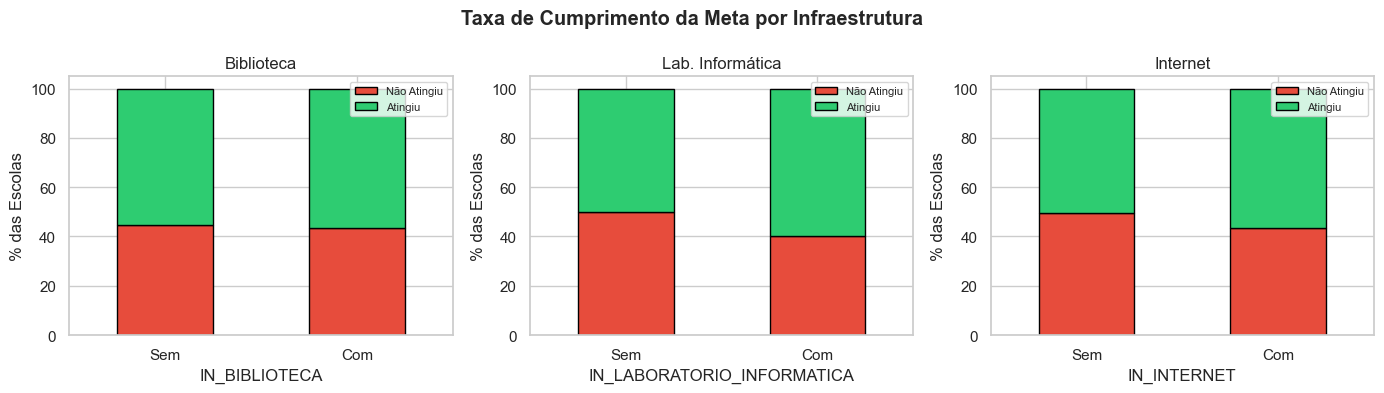

In [6]:
infra_cols = ['IN_BIBLIOTECA', 'IN_LABORATORIO_INFORMATICA', 'IN_INTERNET']
infra_labels = ['Biblioteca', 'Lab. Informática', 'Internet']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(axes, infra_cols, infra_labels):
    if col in df_model.columns:
        ct = pd.crosstab(df_model[col], df_model['ATINGIU_META'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], edgecolor='black', ax=ax)
        ax.set_title(label)
        ax.set_xticklabels(['Sem', 'Com'], rotation=0)
        ax.set_ylabel('% das Escolas')
        ax.legend(['Não Atingiu', 'Atingiu'], fontsize=8)
    else:
        ax.text(0.5, 0.5, f'Coluna {col}\nnão encontrada', ha='center', va='center')

plt.suptitle('Taxa de Cumprimento da Meta por Infraestrutura', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DADOS_TRATADOS, 'eda_infraestrutura.png'), bbox_inches='tight')
plt.show()

### 3d. ATINGIU_META por Rede de Ensino (TP_DEPENDENCIA)

A variável `TP_DEPENDENCIA` indica a rede administrativa da escola: 1 = Federal, 2 = Estadual, 3 = Municipal, 4 = Privada.

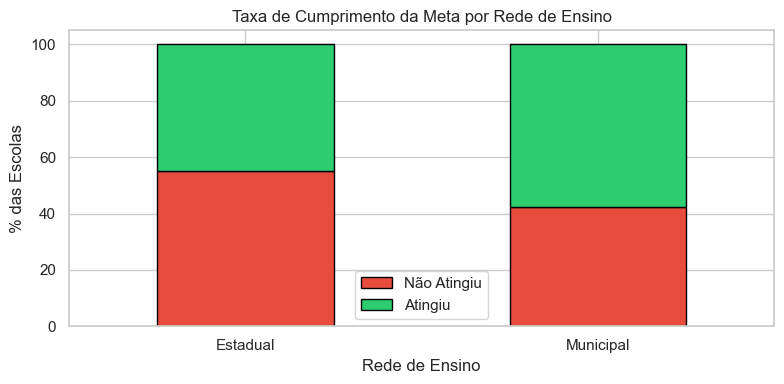

In [7]:
dep_labels = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}

if 'TP_DEPENDENCIA' in df_model.columns:
    ct = pd.crosstab(df_model['TP_DEPENDENCIA'].map(dep_labels), df_model['ATINGIU_META'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], edgecolor='black', figsize=(8, 4))
    plt.title('Taxa de Cumprimento da Meta por Rede de Ensino')
    plt.xlabel('Rede de Ensino')
    plt.ylabel('% das Escolas')
    plt.legend(['Não Atingiu', 'Atingiu'])
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(DADOS_TRATADOS, 'eda_rede_ensino.png'), bbox_inches='tight')
    plt.show()

### 3e. ATINGIU_META por Localização (TP_LOCALIZACAO)

A variável `TP_LOCALIZACAO` indica se a escola é urbana (1) ou rural (2).

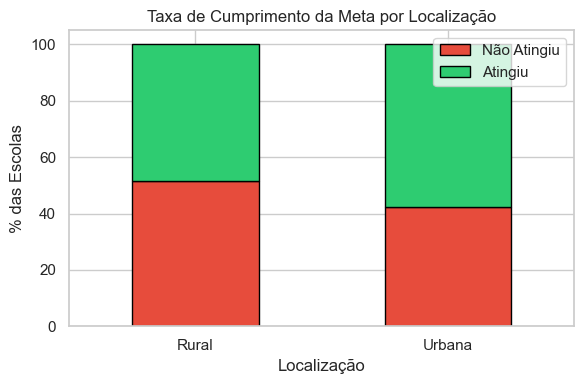

In [8]:
loc_labels = {1: 'Urbana', 2: 'Rural'}

if 'TP_LOCALIZACAO' in df_model.columns:
    ct = pd.crosstab(df_model['TP_LOCALIZACAO'].map(loc_labels), df_model['ATINGIU_META'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], edgecolor='black', figsize=(6, 4))
    plt.title('Taxa de Cumprimento da Meta por Localização')
    plt.xlabel('Localização')
    plt.ylabel('% das Escolas')
    plt.legend(['Não Atingiu', 'Atingiu'])
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(DADOS_TRATADOS, 'eda_localizacao.png'), bbox_inches='tight')
    plt.show()

---
## 4. Definição das Features Candidatas e Engenharia de Variáveis

A partir do Censo Escolar, selecionamos um conjunto de variáveis candidatas a features que representam a infraestrutura, o corpo docente/discente e o contexto administrativo de cada escola. Criamos também a variável derivada `ALUNOS_POR_TURMA` (razão entre matrículas e turmas nos anos iniciais), que é um indicador de densidade de alunos por sala.

**Variáveis excluídas de antemão** (prevenção de data leakage): `IDEB`, `IDEB_META`, `ATINGIU_META`, e todas as colunas `VL_OBSERVADO_*` e `VL_PROJECAO_*`, pois compõem ou derivam diretamente da variável alvo.

In [9]:
# Definição das colunas candidatas
COLUNAS_BINARIAS = [
    'IN_BIBLIOTECA', 'IN_LABORATORIO_INFORMATICA', 'IN_LABORATORIO_CIENCIAS',
    'IN_INTERNET', 'IN_QUADRA_ESPORTES', 'IN_QUADRA_ESPORTES_COBERTA',
    'IN_ACESSIBILIDADE_RAMPAS', 'IN_BANHEIRO_PNE', 'IN_BANDA_LARGA', 'IN_COMPUTADOR'
]

COLUNAS_NUMERICAS = [
    'QT_DOC_FUND_AI', 'QT_MAT_FUND_AI', 'QT_TUR_FUND_AI',
    'QT_DESKTOP_ALUNO', 'ALUNOS_POR_TURMA'
]

COLUNAS_CATEGORICAS = ['TP_DEPENDENCIA', 'TP_LOCALIZACAO']

# Engenharia de feature: criar ALUNOS_POR_TURMA
df_model = criar_alunos_por_turma(df_model)
print(f'Coluna ALUNOS_POR_TURMA criada.')
print(f'Exemplos: {df_model["ALUNOS_POR_TURMA"].head(5).tolist()}')

Coluna ALUNOS_POR_TURMA criada.
Exemplos: [20.541666666666668, 20.8, 21.1, 22.625, 26.2]


### 3f. Contagem de Valores Faltantes nas Features Candidatas

Antes de aplicar o tratamento de valores faltantes, é importante entender a extensão dos dados ausentes em cada variável candidata.

In [10]:
todas_candidatas = COLUNAS_BINARIAS + COLUNAS_NUMERICAS + COLUNAS_CATEGORICAS
existentes = [c for c in todas_candidatas if c in df_model.columns]
faltantes = df_model[existentes].isnull().sum().sort_values(ascending=False)
faltantes_positivos = faltantes[faltantes > 0]

if len(faltantes_positivos) > 0:
    print('Colunas com valores faltantes (NaN):')
    for col, qtd in faltantes_positivos.items():
        print(f'  {col}: {qtd} ({qtd/len(df_model)*100:.1f}%)')
else:
    print('Nenhuma coluna candidata possui valores faltantes.')

Nenhuma coluna candidata possui valores faltantes.


---
## 5. Tratamento de Valores Faltantes

Para as **colunas binárias de infraestrutura** (`IN_*`), os valores faltantes são preenchidos com **0** (zero). Essa decisão se justifica porque, nos microdados do Censo Escolar, quando uma escola não preenche o campo de um recurso de infraestrutura, a interpretação mais provável é que o recurso não está disponível na escola. O valor 0 indica "ausência do recurso", o que é consistente com a semântica dessas variáveis.

Para as **colunas numéricas contínuas** (`QT_*`, `ALUNOS_POR_TURMA`), a imputação é feita com a **mediana** da coluna, uma escolha robusta a outliers (ao contrário da média, que pode ser distorcida por valores extremos).

In [11]:
df_model, relatorio_faltantes = tratar_faltantes_features(df_model, COLUNAS_BINARIAS, COLUNAS_NUMERICAS)

if relatorio_faltantes:
    print('Valores faltantes tratados:')
    for col, qtd in relatorio_faltantes.items():
        print(f'  {col}: {qtd} NaNs preenchidos')
else:
    print('Nenhum valor faltante foi encontrado nas features candidatas.')

# Confirmar que não restam NaNs
existentes_apos = [c for c in COLUNAS_BINARIAS + COLUNAS_NUMERICAS if c in df_model.columns]
restantes = df_model[existentes_apos].isnull().sum().sum()
print(f'\nTotal de NaN restantes nas features: {restantes}')

Nenhum valor faltante foi encontrado nas features candidatas.

Total de NaN restantes nas features: 0


---
## 6. Codificação de Variáveis Categóricas

As variáveis `TP_DEPENDENCIA` (rede de ensino) e `TP_LOCALIZACAO` (urbana/rural) são categóricas ordinais. Aplicamos `pd.get_dummies()` para transformá-las em variáveis binárias (one-hot encoding), permitindo que os modelos de aprendizagem de máquina as interpretem corretamente.

In [12]:
# One-hot encoding
df_model = pd.get_dummies(df_model, columns=COLUNAS_CATEGORICAS, prefix=COLUNAS_CATEGORICAS, dtype=float)

# Listar as novas colunas criadas
# Nota: exclui TP_LOCALIZACAO_DIFERENCIADA pois é uma coluna original do Censo, não um dummy
colunas_dummies = [
    c for c in df_model.columns
    if (c.startswith('TP_DEPENDENCIA_') or c.startswith('TP_LOCALIZACAO_'))
    and c != 'TP_LOCALIZACAO_DIFERENCIADA'
]
print(f'Colunas criadas por get_dummies ({len(colunas_dummies)}):')
for col in colunas_dummies:
    print(f'  {col}')

Colunas criadas por get_dummies (4):
  TP_DEPENDENCIA_2
  TP_DEPENDENCIA_3
  TP_LOCALIZACAO_1
  TP_LOCALIZACAO_2


---
## 7. Seleção de Features por Correlação com o Alvo

A seleção de features segue a **metodologia ensinada na disciplina**, conforme o material de referência sobre overfitting e regularização (exemplo do dataset `heart_failure_clinical_records`). A técnica consiste em:

1. Calcular a **matriz de correlação de Pearson** entre todas as variáveis candidatas e a variável alvo.
2. Visualizar a matriz como **heatmap** (seaborn) para identificar padrões.
3. Selecionar como preditoras apenas as variáveis cuja **correlação em módulo (valor absoluto)** com o alvo seja superior ao limiar definido.

O limiar padrão utilizado no exemplo da disciplina é **0,1**. Caso menos de 4 features ultrapassem esse limiar, ele é reduzido automaticamente para **0,05**, uma vez que as correlações individuais com a variável alvo tendem a ser baixas quando o fenômeno depende da combinação de múltiplos fatores (como é o caso do desempenho educacional).

In [22]:
# Montar dataframe com features candidatas + alvo
features_candidatas = COLUNAS_BINARIAS + COLUNAS_NUMERICAS + colunas_dummies
existentes_final = [c for c in features_candidatas if c in df_model.columns]

df_corr = df_model[existentes_final + ['ATINGIU_META']].copy()

# Tentar primeiro com limiar 0.1 (padrão da disciplina)
LIMIAR = 0.1
correlacoes, selecionadas, descartadas = selecionar_features_por_correlacao(df_corr, 'ATINGIU_META', limiar=LIMIAR, remover_redundantes=['TP_LOCALIZACAO_2'])

# Se menos de 4 features passaram, reduzir o limiar para 0.05
if len(selecionadas) < 4:
    print(f'Apenas {len(selecionadas)} features passaram no limiar de {LIMIAR}.')
    LIMIAR = 0.05
    print(f'Reduzindo o limiar para {LIMIAR} para garantir um número mínimo de preditores.')
    print(f'Justificativa: as correlações individuais são baixas porque a variável alvo (ATINGIU_META)')
    print(f'depende da combinação de múltiplos fatores, não de um único indicador isoladamente.')
    print()
    correlacoes, selecionadas, descartadas = selecionar_features_por_correlacao(df_corr, 'ATINGIU_META', limiar=LIMIAR, remover_redundantes=['TP_LOCALIZACAO_2'])

print(f'Correlação de cada feature com ATINGIU_META (ordenada por |corr|, limiar={LIMIAR}):')
print('-' * 55)
for feat, corr in correlacoes.items():
    status = '✅ SELECIONADA' if feat in selecionadas else '   descartada'
    print(f'  {feat:<35} {corr:>+.4f}  [{status}]')

print(f'\nFeatures selecionadas (|corr| > {LIMIAR}): {len(selecionadas)}')
print(f'Features descartadas: {len(descartadas)}')

Apenas 0 features passaram no limiar de 0.1.
Reduzindo o limiar para 0.05 para garantir um número mínimo de preditores.
Justificativa: as correlações individuais são baixas porque a variável alvo (ATINGIU_META)
depende da combinação de múltiplos fatores, não de um único indicador isoladamente.

Correlação de cada feature com ATINGIU_META (ordenada por |corr|, limiar=0.05):
-------------------------------------------------------
  QT_MAT_FUND_AI                      +0.0975  [✅ SELECIONADA]
  IN_LABORATORIO_INFORMATICA          +0.0951  [✅ SELECIONADA]
  TP_DEPENDENCIA_2                    -0.0942  [✅ SELECIONADA]
  TP_DEPENDENCIA_3                    +0.0942  [✅ SELECIONADA]
  QT_DOC_FUND_AI                      +0.0920  [✅ SELECIONADA]
  QT_TUR_FUND_AI                      +0.0864  [✅ SELECIONADA]
  TP_LOCALIZACAO_1                    +0.0772  [✅ SELECIONADA]
  TP_LOCALIZACAO_2                    -0.0772  [   descartada]
  IN_BANHEIRO_PNE                     +0.0638  [✅ SELECIONADA]
 

Entre as features selecionadas pelo critério de correlação, identificamos que `TP_LOCALIZACAO_1` e `TP_LOCALIZACAO_2` são redundantes entre si, pois representam as duas únicas categorias de uma variável binária (localização urbana/rural) após one-hot encoding — uma é sempre o complemento exato da outra. Mantemos apenas `TP_LOCALIZACAO_1` e removemos `TP_LOCALIZACAO_2`, pois manter as duas não adiciona informação nova ao modelo, apenas redundância desnecessária (dummy variable trap)

Note que não promovemos a próxima feature da lista de descartadas para substituir a removida, pois isso seria inconsistente com o critério de correlação > 0.05 que definimos: a próxima colocada (`IN_COMPUTADOR`, corr = 0.0454) está abaixo do limiar estabelecido, e incluí-la apenas para completar um número redondo de features não teria justificativa metodológica. O dataset final de features passa a ter 8 colunas.

In [23]:
# A remoção de TP_LOCALIZACAO_2 foi tratada pela função selecionar_features_por_correlacao()
print(f'Lista final de features selecionadas ({len(selecionadas)} colunas):')
for i, col in enumerate(selecionadas, 1):
    print(f'  {i}. {col}')

Lista final de features selecionadas (8 colunas):
  1. QT_MAT_FUND_AI
  2. IN_LABORATORIO_INFORMATICA
  3. TP_DEPENDENCIA_2
  4. TP_DEPENDENCIA_3
  5. QT_DOC_FUND_AI
  6. QT_TUR_FUND_AI
  7. TP_LOCALIZACAO_1
  8. IN_BANHEIRO_PNE


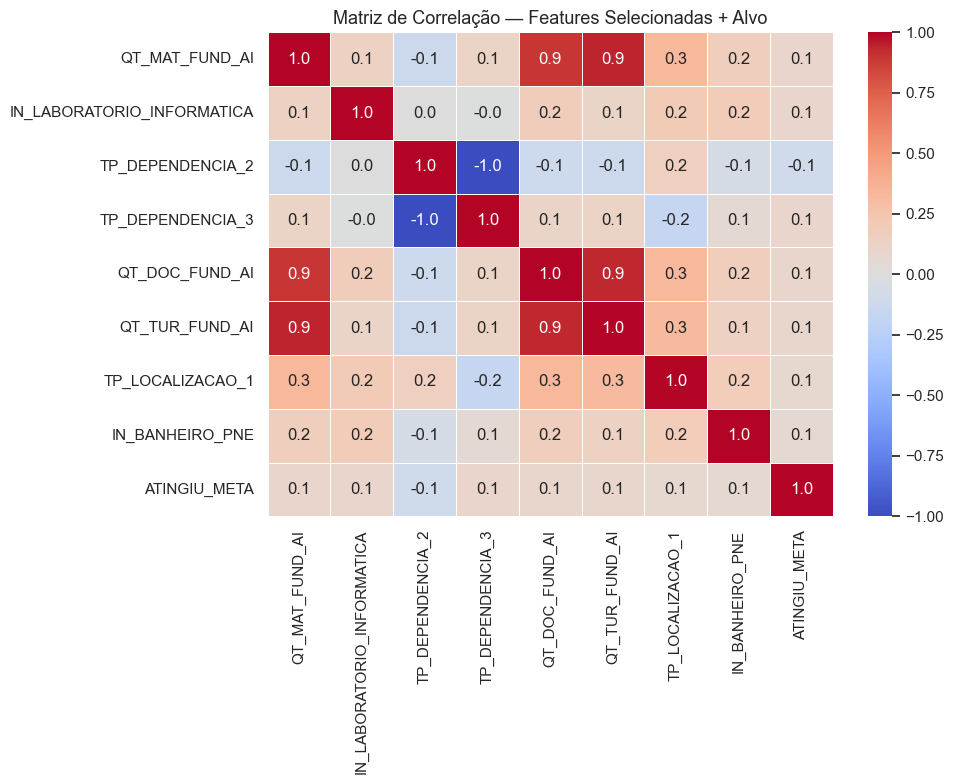

In [15]:
# Heatmap da matriz de correlação (features selecionadas + alvo)
df_heatmap = df_model[selecionadas + ['ATINGIU_META']].copy()
correlation = df_heatmap.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(max(10, len(selecionadas) * 0.9), max(8, len(selecionadas) * 0.7)))
sns.heatmap(correlation, annot=True, fmt='.1f', linewidths=.6,
            cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlação — Features Selecionadas + Alvo', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DADOS_TRATADOS, 'heatmap_correlacao.png'), bbox_inches='tight')
plt.show()

---
## 8. Definição de X e y

Com base na seleção por correlação, definimos `X` (matriz de features) e `y` (variável alvo).

In [24]:
X = df_model[selecionadas].copy()
y = df_model['ATINGIU_META'].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeatures utilizadas ({len(selecionadas)}):')
for i, col in enumerate(selecionadas, 1):
    print(f'  {i}. {col}')

X shape: (3343, 8)
y shape: (3343,)

Features utilizadas (8):
  1. QT_MAT_FUND_AI
  2. IN_LABORATORIO_INFORMATICA
  3. TP_DEPENDENCIA_2
  4. TP_DEPENDENCIA_3
  5. QT_DOC_FUND_AI
  6. QT_TUR_FUND_AI
  7. TP_LOCALIZACAO_1
  8. IN_BANHEIRO_PNE


---
## 9. Divisão Treino/Teste (Estratificada)

Utilizamos `train_test_split` com `test_size=0.2` (80% treino / 20% teste) e `random_state=42` para reprodutibilidade. O parâmetro `stratify=y` garante que a **proporção entre as classes** (atingiu vs. não atingiu a meta) seja mantida tanto no conjunto de treino quanto no de teste. Essa técnica é especialmente importante quando há desbalanceamento entre as classes, como observado na análise exploratória (seção 3a), pois evita que o conjunto de teste contenha uma distribuição distorcida da variável alvo.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print(f'\nDistribuição do alvo no treino:')
print(y_train.value_counts())
print(f'\nDistribuição do alvo no teste:')
print(y_test.value_counts())

X_train: (2674, 8) | y_train: (2674,)
X_test:  (669, 8)  | y_test:  (669,)

Distribuição do alvo no treino:
ATINGIU_META
1.0    1489
0.0    1185
Name: count, dtype: int64

Distribuição do alvo no teste:
ATINGIU_META
1.0    372
0.0    297
Name: count, dtype: int64


---
## 10. Normalização com StandardScaler

Aplicamos o `StandardScaler` (padronização z-score) nos dados de treino e teste. Essa normalização é importante porque o nosso conjunto de features combina **variáveis binárias** (0/1, como `IN_BIBLIOTECA`) com **variáveis contínuas** de escalas muito diferentes (como `QT_MAT_FUND_AI`, que pode chegar a centenas de alunos, ou `ALUNOS_POR_TURMA`). Sem normalização, as variáveis de maior escala dominariam o cálculo de distâncias e gradientes na rede neural.

O `fit` é realizado **apenas no conjunto de treino** para evitar data leakage — o conjunto de teste é transformado com os mesmos parâmetros (média e desvio padrão) aprendidos no treino.

In [18]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Estatísticas após normalização (treino):')
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))

Estatísticas após normalização (treino):
      QT_MAT_FUND_AI  IN_LABORATORIO_INFORMATICA  TP_DEPENDENCIA_2  \
mean         -0.0000                     -0.0000           -0.0000   
std           1.0002                      1.0002            1.0002   

      TP_DEPENDENCIA_3  QT_DOC_FUND_AI  QT_TUR_FUND_AI  TP_LOCALIZACAO_1  \
mean            0.0000          0.0000         -0.0000            0.0000   
std             1.0002          1.0002          1.0002            1.0002   

      IN_BANHEIRO_PNE  
mean           0.0000  
std            1.0002  


---
## 11. Resumo Final: Dimensões para Modelagem

As dimensões de N (amostras) e p (features) serão usadas nos notebooks seguintes para o dimensionamento da rede neural e cálculo da dimensão VC.

In [19]:
N_treino = X_train_scaled.shape[0]
p_features = X_train_scaled.shape[1]

print('=== DIMENSÕES FINAIS ===')
print(f'X_train: {X_train_scaled.shape}')
print(f'X_test:  {X_test_scaled.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')
print(f'\nN (amostras de treino): {N_treino}')
print(f'p (número de features):  {p_features}')
print(f'\nEssas informações serão usadas para o cálculo da dimensão VC da rede neural.')

=== DIMENSÕES FINAIS ===
X_train: (2674, 8)
X_test:  (669, 8)
y_train: (2674,)
y_test:  (669,)

N (amostras de treino): 2674
p (número de features):  8

Essas informações serão usadas para o cálculo da dimensão VC da rede neural.


---
## 12. Exportação dos Conjuntos de Treino e Teste

In [20]:
X_train_scaled.to_csv(os.path.join(DADOS_TRATADOS, 'X_train.csv'), index=False)
X_test_scaled.to_csv(os.path.join(DADOS_TRATADOS, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(DADOS_TRATADOS, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(DADOS_TRATADOS, 'y_test.csv'), index=False)

print('Arquivos salvos em dados_tratados/:')
for f in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']:
    path = os.path.join(DADOS_TRATADOS, f)
    size = os.path.getsize(path) / 1024
    print(f'  {f}: {size:.1f} KB')

Arquivos salvos em dados_tratados/:
  X_train.csv: 411.0 KB
  X_test.csv: 103.0 KB
  y_train.csv: 10.5 KB
  y_test.csv: 2.6 KB
